## Hidden Markov model demo

### 1. Setup

In [1]:
# import autograd.numpy as np
# import autograd.numpy.random as npr
# npr.seed(0)
import ssm
from ssm.util import find_permutation
from ssm.plots import gradient_cmap, white_to_color_cmap
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline

import seaborn as sns
sns.set_style("white")
sns.set_context("talk")

color_names = [
    "windows blue",
    "red",
    "amber",
    "faded green",
    "dusty purple",
    "orange"
    ]

colors = sns.xkcd_palette(color_names)
cmap = gradient_cmap(colors)


# Speficy whether or not to save figures
save_figures = True

#### Structure of the HMM function from ssm

 ```true_hmm = ssm.HMM(K, D, observations="gaussian")```

where K corresponds to the number of hidden states, D corresponds to the dimensionality of the observed variable and finally the observation type which is in this case described as gaussian

#### Observations setup in order to simulate the hmm

In [2]:
# Set the parameters of the HMM
time_bins = 399   # number of rows in the data
num_states = 2   # number of starting test states
obs_dim = 2     # dimensionality of observation

obs = pd.read_csv('traindata.csv')
obs = obs.astype(np.int64)  # Direct conversion
data = obs[['hit', 'side']].values
print(obs['hit'].dtype)  # Should output `int64` or `float64`
print(obs['hit'].unique())  # Check actual unique values
print(obs['choice'].dtype)  # Should output `int64` or `float64`
print(obs['choice'].unique())  # Check actual unique values
print(obs['side'].dtype)  # Should output `int64` or `float64`
print(obs['side'].unique())  # Check actual unique values


FileNotFoundError: [Errno 2] File traindata.csv does not exist: 'traindata.csv'

In [56]:
# Set the parameters of the HMM
time_bins = 399   # number of rows in the data
num_states = 2   # number of starting test states
obs_dim = 2     # dimensionality of observation

obs = pd.read_csv('traindata.csv')
obs = obs.astype(bool)  # Direct conversion
data = obs[['choice', 'side']].values
print(obs['hit'].dtype)  # Should output `int64` or `float64`
print(obs['hit'].unique())  # Check actual unique values
print(obs['choice'].dtype)  # Should output `int64` or `float64`
print(obs['choice'].unique())  # Check actual unique values
print(obs['side'].dtype)  # Should output `int64` or `float64`
print(obs['side'].unique())  # Check actual unique values


bool
[False  True]
bool
[False  True]
bool
[ True False]


In [57]:
test = obs.choice

In [58]:
print(data.shape)
print(data)

(399, 2)
[[False  True]
 [False False]
 [ True  True]
 [False False]
 [ True  True]
 [False False]
 [ True  True]
 [False False]
 [ True  True]
 [False False]
 [ True  True]
 [False False]
 [ True  True]
 [False False]
 [ True  True]
 [False False]
 [ True  True]
 [False False]
 [ True  True]
 [ True  True]
 [ True  True]
 [False False]
 [False False]
 [ True  True]
 [ True  True]
 [ True  True]
 [False False]
 [ True  True]
 [ True  True]
 [ True  True]
 [ True  True]
 [False False]
 [False False]
 [ True  True]
 [ True  True]
 [False False]
 [ True  True]
 [False False]
 [ True  True]
 [False False]
 [False False]
 [False False]
 [ True  True]
 [False False]
 [ True  True]
 [False False]
 [False False]
 [False False]
 [False  True]
 [False False]
 [False False]
 [False False]
 [False  True]
 [ True  True]
 [False  True]
 [False False]
 [False False]
 [False  True]
 [False False]
 [ True  True]
 [False False]
 [False False]
 [False False]
 [False False]
 [False False]
 [False False]
 

### Fit an HMM to real data

```hmm = ssm.HMM(num_states, obs_dim, observations="bernoulli") hmm_lls = hmm.fit(obs, method="em", num_em_iters=N_iters)```

In the first line, we create a new HMM instance called hmm with a bernoulli observation model

In [67]:

N_iters = 50

## testing the constrained transitions class
hmm = ssm.HMM(num_states, obs_dim, observations="bernoulli")

hmm_bernoulli = hmm.fit(data, method="em", num_iters=N_iters, init_method="kmeans")


  0%|          | 0/50 [00:00<?, ?it/s]

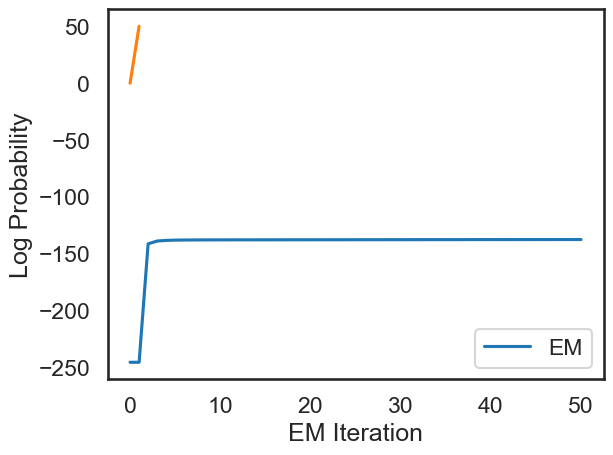

In [68]:
plt.plot(hmm_bernoulli, label="EM")
plt.plot([0, N_iters])
plt.xlabel("EM Iteration")
plt.ylabel("Log Probability")
plt.legend(loc="lower right")
plt.show()


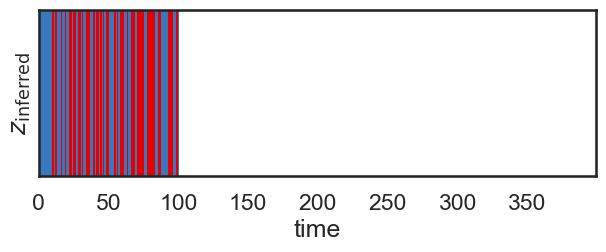

In [69]:
hmm_b = hmm.most_likely_states(data)
plt.subplot(211)
plt.imshow(hmm_b[None,:], aspect="auto", cmap=cmap, vmin=0, vmax=len(colors)-1)
plt.xlim(0, time_bins)
plt.ylabel("$z_{\\mathrm{inferred}}$")
plt.yticks([])
plt.xlabel("time")

plt.tight_layout()

he below cell is a bit subtle. In the first section, we sampled from the HMM and stored the resulting latent state in a variable called ```state```. Now, we are treating our observations from the previous section as data, and seeing whether we can infer the true state given only the observations. However, there is no guarantee that the states we learn correspond to the original states from the true HMM. In order to account for this, we need to find a permutation of the states of our new HMM so that they align with the states of the true HMM from the prior section. This is done in the following two lines:

```most_likely_states = hmm.most_likely_states(obs) hmm.permute(find_permutation(true_states, most_likely_states))```

In the first line, we use the ```most_likely_states``` method to infer the most likely latent states given the observations. In the second line we call the ```find_permutation``` function the permutation that best matches the true state. We then use the ```permute``` method on our ```hmm``` instance to permute its states accordingly.

In [20]:
# Find a permutation of the states that best matches the true and inferred states
most_likely_states = hmm.most_likely_states(obs)
hmm.permute(find_permutation(true_states, most_likely_states))

Here we will plot both the inferred states as well as the true states in order to compare and understand model performance. We can identify how short state dwell negatively affects model performance


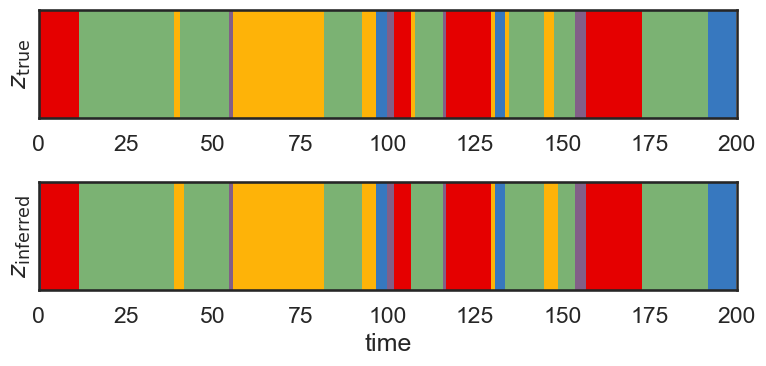

In [21]:
# Plot the true and inferred discrete states
hmm_z = hmm.most_likely_states(data)

plt.figure(figsize=(8, 4))
plt.subplot(211)
plt.imshow(true_states[None,:], aspect="auto", cmap=cmap, vmin=0, vmax=len(colors)-1)
plt.xlim(0, time_bins)
plt.ylabel("$z_{\\mathrm{true}}$")
plt.yticks([])

plt.subplot(212)
plt.imshow(hmm_z[None,:], aspect="auto", cmap=cmap, vmin=0, vmax=len(colors)-1)
plt.xlim(0, time_bins)
plt.ylabel("$z_{\\mathrm{inferred}}$")
plt.yticks([])
plt.xlabel("time")

plt.tight_layout()

Text(0.5, 0, 'time')

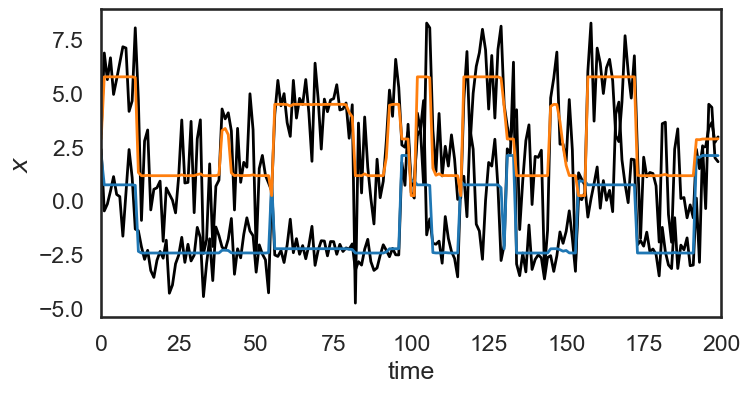

In [22]:
# Use the HMM to "smooth" the data
hmm_x = hmm.smooth(obs)

plt.figure(figsize=(8, 4))
plt.plot(obs + 3 * np.arange(obs_dim), '-k', lw=2)
plt.plot(hmm_x + 3 * np.arange(obs_dim), '-', lw=2)
plt.xlim(0, time_bins)
plt.ylabel("$x$")
# plt.yticks([])
plt.xlabel("time")

#### Visualize the Transition Matrices

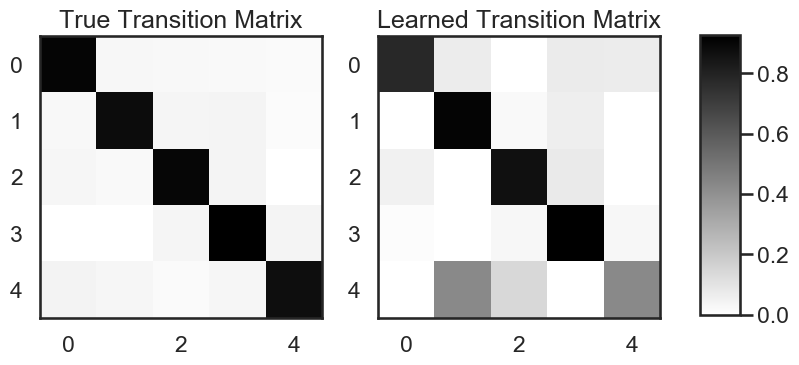

In [23]:
true_transition_mat = true_hmm.transitions.transition_matrix
learned_transition_mat = hmm.transitions.transition_matrix

fig = plt.figure(figsize=(8, 4))
plt.subplot(121)
im = plt.imshow(true_transition_mat, cmap='gray_r')
plt.title("True Transition Matrix")

plt.subplot(122)
im = plt.imshow(learned_transition_mat, cmap='gray_r')
plt.title("Learned Transition Matrix")

cbar_ax = fig.add_axes([0.95, 0.15, 0.05, 0.7])
fig.colorbar(im, cax=cbar_ax)
plt.show()

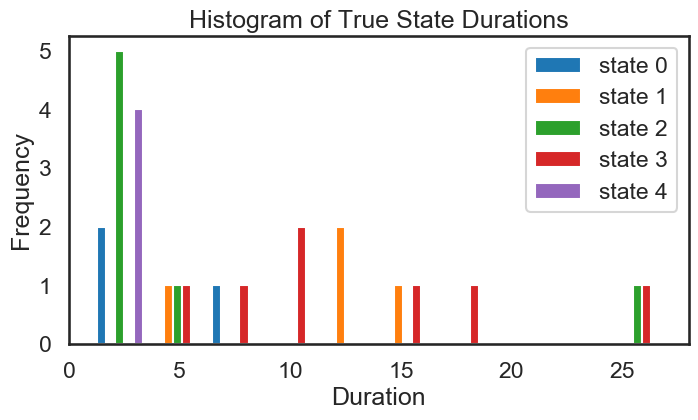

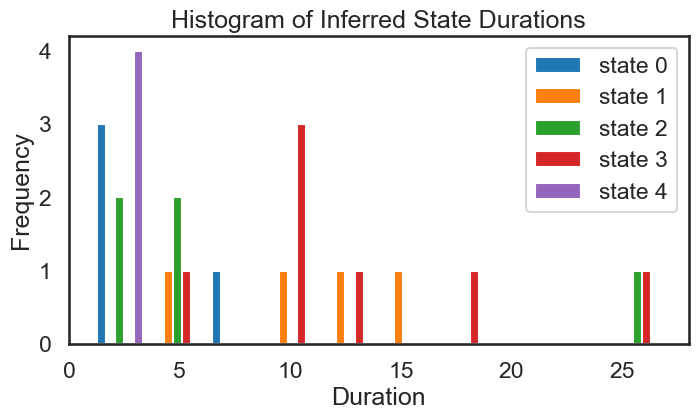

In [24]:
true_state_list, true_durations = ssm.util.rle(true_states)
inferred_state_list, inferred_durations = ssm.util.rle(hmm_z)

# Rearrange the lists of durations to be a nested list where
# the nth inner list is a list of durations for state n
true_durs_stacked = []
inf_durs_stacked = []
for s in range(num_states):
    true_durs_stacked.append(true_durations[true_state_list == s])
    inf_durs_stacked.append(inferred_durations[inferred_state_list == s])

fig = plt.figure(figsize=(8, 4))
plt.hist(true_durs_stacked, label=['state ' + str(s) for s in range(num_states)])
plt.xlabel('Duration')
plt.ylabel('Frequency')
plt.legend()
plt.title('Histogram of True State Durations')

fig = plt.figure(figsize=(8, 4))
plt.hist(inf_durs_stacked, label=['state ' + str(s) for s in range(num_states)])
plt.xlabel('Duration')
plt.ylabel('Frequency')
plt.legend()
plt.title('Histogram of Inferred State Durations')

plt.show()


In [25]:
# Set the parameters of the HMM
time_bins = 200   # number of time bins
num_states = 5    # number of discrete states
obs_dim = 2       # dimensionality of observation

# Make an HMM
true_hmm = ssm.HMM(num_states, obs_dim, observations="gaussian")

# Manually tweak the means to make them farther apart
thetas = np.linspace(0, 2 * np.pi, num_states, endpoint=False)
true_hmm.observations.mus = 3 * np.column_stack((np.cos(thetas), np.sin(thetas)))
# Sample some data from the HMM
true_states, obs = true_hmm.sample(time_bins)
true_ll = true_hmm.log_probability(obs)
# Plot the observation distributions
lim = .85 * abs(obs).max()
XX, YY = np.meshgrid(np.linspace(-lim, lim, 100), np.linspace(-lim, lim, 100))
data = np.column_stack((XX.ravel(), YY.ravel()))
input = np.zeros((data.shape[0], 0))
mask = np.ones_like(data, dtype=bool)
tag = None
lls = true_hmm.observations.log_likelihoods(data, input, mask, tag)

#### fit

  0%|          | 0/50 [00:00<?, ?it/s]

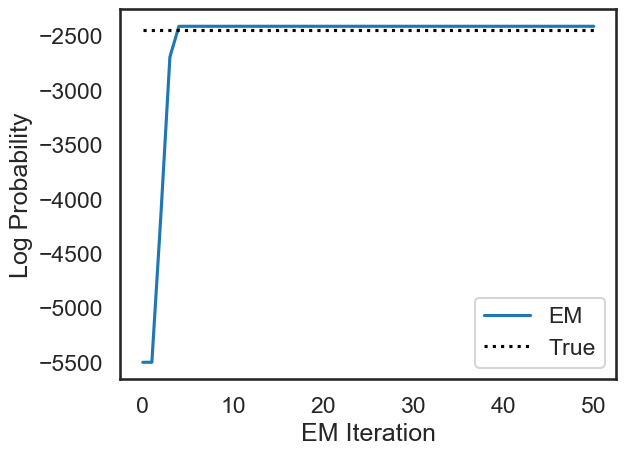